In [1]:
# Install required libraries
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn joblib

print("Libraries installed successfully!")

Libraries installed successfully!


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Download the UCI Individual Household Electric Power Consumption Dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
download_path = '/content/household_power_consumption.zip'

print("Downloading UCI Smart Meter Dataset...")
urllib.request.urlretrieve(url, download_path)
print("Download complete!")

# Extract the zip file
import zipfile
with zipfile.ZipFile(download_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Extraction complete!")
os.remove(download_path)

# Verify files
print("\nFiles in /content:")
print(os.listdir('/content'))

Download complete!
Extraction complete!

Files in /content:
['.config', 'household_power_consumption.txt', 'sample_data']


In [4]:
# Load the dataset
file_path = '/content/household_power_consumption.txt'

# The UCI dataset uses semicolon separator
df = pd.read_csv(file_path, sep=';', low_memory=False)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (2075259, 9)

First few rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [5]:
# Data Info
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Column Names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Data Types:
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

Basic Statistics:


,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [7]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Convert columns to numeric
for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Create datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.set_index('datetime')
df = df.drop(['Date', 'Time'], axis=1)

print("After preprocessing:")
print(df.shape)
print("\nMissing values after conversion:")
print(df.isnull().sum())

After preprocessing:
(2075259, 7)

Missing values after conversion:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [8]:
# Handle missing values - forward fill then backward fill
df = df.fillna(method='ffill').fillna(method='bfill')

# Check if any missing values remain
print("Missing values after filling:", df.isnull().sum().sum())

# Use Global_active_power as target variable for forecasting
target_col = 'Global_active_power'
df = df[[target_col]].copy()

print("\nTarget variable shape:", df.shape)
df.head()

Missing values after filling: 0

Target variable shape: (2075259, 1)


,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [9]:
# Resample data to hourly for better modeling (reduce computation)
df_resampled = df.resample('H').mean()

print("Resampled data shape (hourly):", df_resampled.shape)

# Create time-based features
df_resampled['hour'] = df_resampled.index.hour
df_resampled['day_of_week'] = df_resampled.index.dayofweek
df_resampled['month'] = df_resampled.index.month
df_resampled['day_of_year'] = df_resampled.index.dayofyear

# Create lag features for time-series
for lag in [1, 2, 3, 6, 12, 24]:
    df_resampled[f'lag_{lag}'] = df_resampled[target_col].shift(lag)

# Create rolling window features
df_resampled['rolling_mean_6'] = df_resampled[target_col].rolling(window=6).mean()
df_resampled['rolling_mean_24'] = df_resampled[target_col].rolling(window=24).mean()
df_resampled['rolling_std_24'] = df_resampled[target_col].rolling(window=24).std()

# Drop rows with NaN due to lag features
df_resampled = df_resampled.dropna()

print("After feature engineering:", df_resampled.shape)
df_resampled.head()

Resampled data shape (hourly): (34589, 1)
After feature engineering: (34565, 14)


,Global_active_power,hour,day_of_week,month,day_of_year,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_6,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,351,3.326033,2.985400,2.092633,2.471000,1.996733,4.222889,2.564578,2.465140,0.752521
2006-12-17 18:00:00,3.697100,18,6,12,351,3.406767,3.326033,2.985400,1.915867,1.303300,3.632200,2.861450,2.467844,0.757001
2006-12-17 19:00:00,2.908400,19,6,12,351,3.697100,3.406767,3.326033,1.660767,1.620033,3.400233,3.069389,2.447351,0.737057
2006-12-17 20:00:00,3.361500,20,6,12,351,2.908400,3.697100,3.406767,2.092633,1.890567,3.268567,3.280867,2.451224,0.741788
2006-12-17 21:00:00,3.040767,21,6,12,351,3.361500,2.908400,3.697100,2.985400,2.549067,3.056467,3.290094,2.450569,0.741237


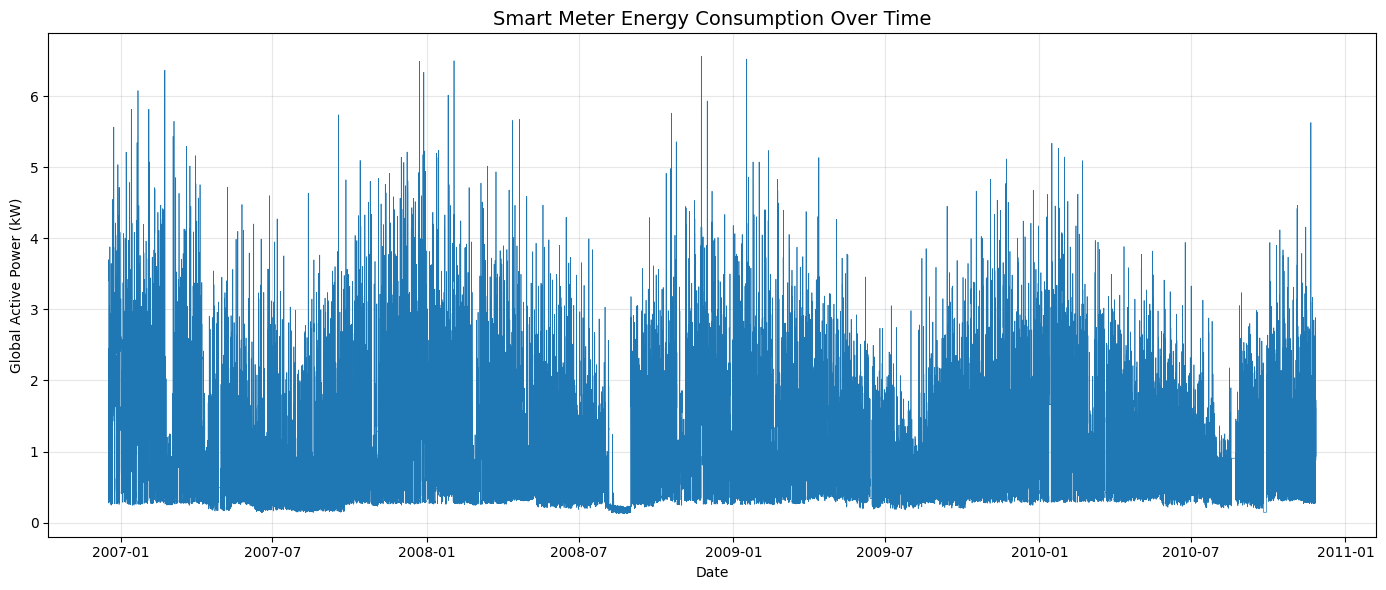

In [10]:
# Plot the time series data
plt.figure(figsize=(14, 6))
plt.plot(df_resampled.index, df_resampled[target_col], linewidth=0.5)
plt.title('Smart Meter Energy Consumption Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

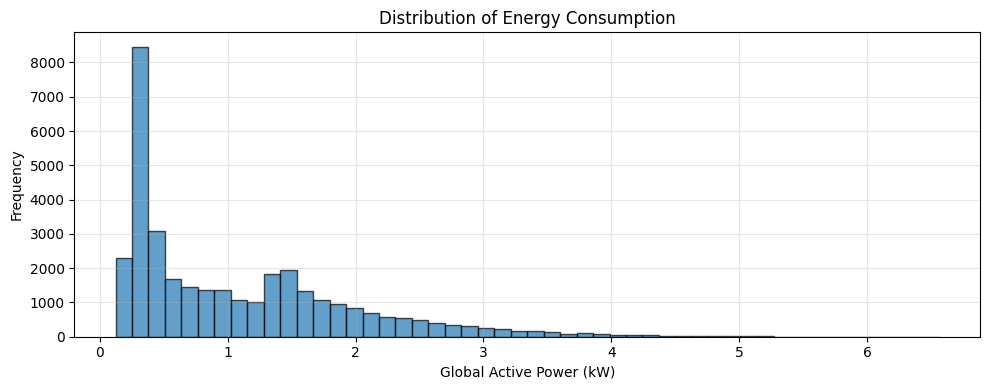

In [11]:
# Distribution of energy consumption
plt.figure(figsize=(10, 4))
plt.hist(df_resampled[target_col], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Energy Consumption')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

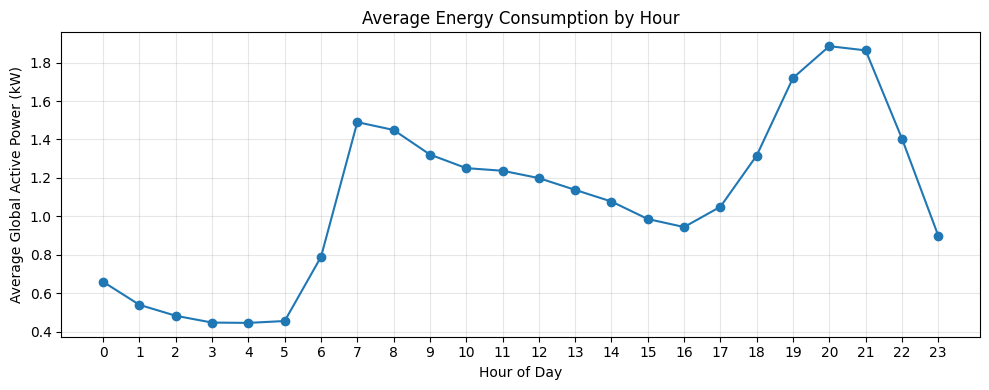

In [12]:
# Average consumption by hour
plt.figure(figsize=(10, 4))
hourly_avg = df_resampled.groupby('hour')[target_col].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Define features and target
feature_columns = [col for col in df_resampled.columns if col != target_col]
X = df_resampled[feature_columns]
y = df_resampled[target_col]

print("Features:", feature_columns)
print("X shape:", X.shape)
print("y shape:", y.shape)

# Split data into train and test sets (80-20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTrain set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Features: ['hour', 'day_of_week', 'month', 'day_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'rolling_mean_6', 'rolling_mean_24', 'rolling_std_24']
X shape: (34565, 13)
y shape: (34565,)

Train set size: 27652
Test set size: 6913


In [14]:
# Scale the features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

print("Data scaling complete!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Data scaling complete!
X_train_scaled shape: (27652, 13)
X_test_scaled shape: (6913, 13)


In [15]:
# Import TensorFlow/Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

# Reshape data for LSTM [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("LSTM input shape:", X_train_lstm.shape)

TensorFlow version: 2.19.0
LSTM input shape: (27652, 1, 13)


In [16]:
# Build LSTM Model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train_scaled.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,929 (128.63 KB)

 Trainable params: 32,929 (128.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train LSTM Model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training LSTM model...")
history = model_lstm.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nLSTM training complete!")

Training LSTM model...
Epoch 1/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0115 - mae: 0.0771 - val_loss: 0.0062 - val_mae: 0.0542
Epoch 2/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0080 - mae: 0.0630 - val_loss: 0.0057 - val_mae: 0.0535
Epoch 3/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0072 - mae: 0.0601 - val_loss: 0.0053 - val_mae: 0.0502
Epoch 4/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0067 - mae: 0.0579 - val_loss: 0.0053 - val_mae: 0.0487
Epoch 5/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0063 - mae: 0.0560 - val_loss: 0.0051 - val_mae: 0.0486
Epoch 6/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0062 - mae: 0.0550 - val_loss: 0.0048 - val_mae: 0.0480
Epoch 7/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0061 - mae: 0.0542 - val_loss: 0.0047 - val_mae: 0.0467
Epoch 8/50
692/692 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0059 - mae: 0.0535 - val_loss: 0.0045 - val_mae: 0.0452
Epoch 9/50
692/692 ━━━━━━━━━━━━━━

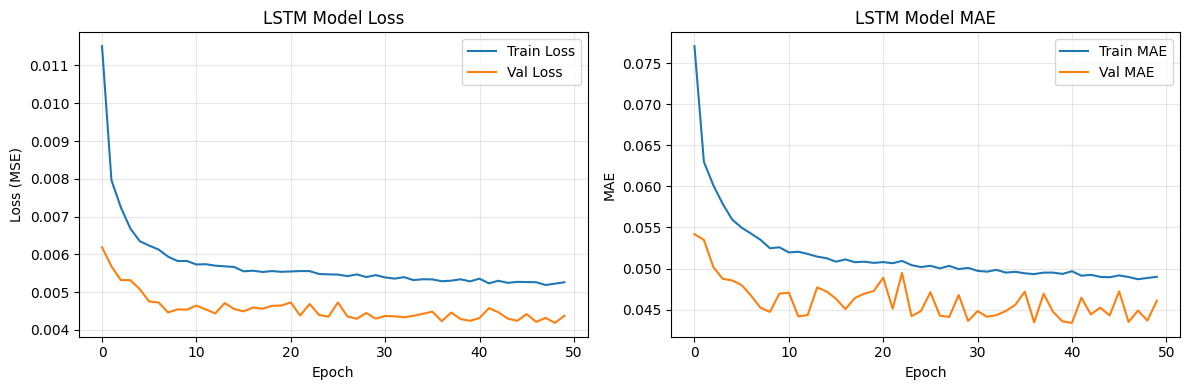

In [18]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('LSTM Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# LSTM Predictions
y_pred_lstm_scaled = model_lstm.predict(X_test_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Calculate LSTM metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
lstm_mae = mean_absolute_error(y_test, y_pred_lstm)
lstm_r2 = r2_score(y_test, y_pred_lstm)

print("LSTM Model Performance:")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE: {lstm_mae:.4f}")
print(f"  R2 Score: {lstm_r2:.4f}")

217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Model Performance:
  RMSE: 0.3815
  MAE: 0.2621
  R2 Score: 0.7274


In [20]:
# Build and Train Random Forest Model
print("Training Random Forest model...")
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_scaled, y_train)
print("Random Forest training complete!")

Training Random Forest model...
Random Forest training complete!


In [21]:
# Random Forest Predictions
y_pred_rf = model_rf.predict(X_test_scaled)

# Calculate Random Forest metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE: {rf_mae:.4f}")
print(f"  R2 Score: {rf_r2:.4f}")

Random Forest Model Performance:
  RMSE: 0.3834
  MAE: 0.2589
  R2 Score: 0.7247


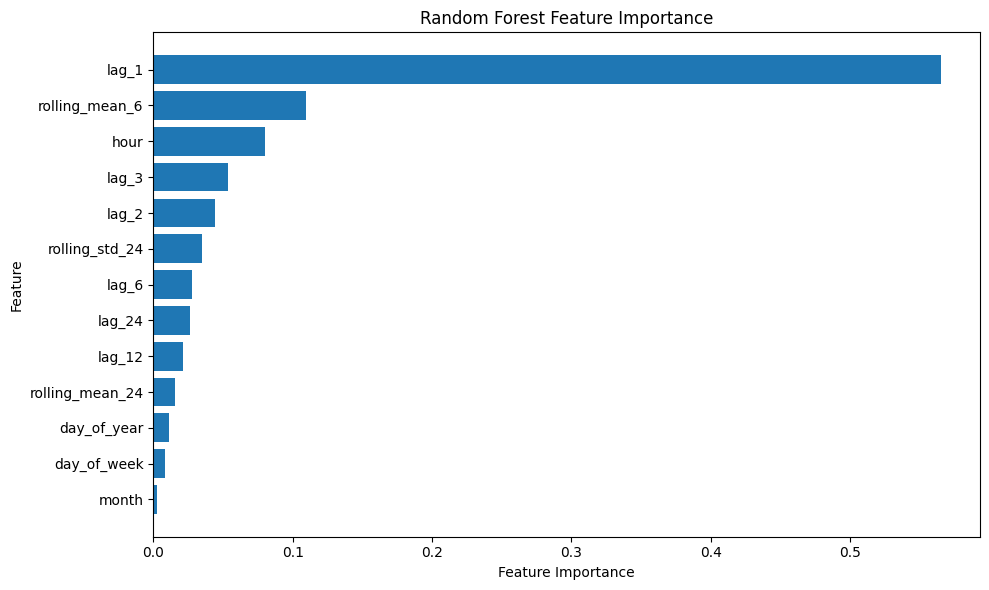


Top 10 Most Important Features:
            feature  importance
4             lag_1    0.565065
10   rolling_mean_6    0.109202
0              hour    0.079984
6             lag_3    0.053687
5             lag_2    0.044004
12   rolling_std_24    0.035157
7             lag_6    0.027916
9            lag_24    0.026306
8            lag_12    0.021577
11  rolling_mean_24    0.015439


In [22]:
# Feature Importance for Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

In [23]:
# Compare Model Performance
results = pd.DataFrame({
    'Model': ['LSTM', 'Random Forest'],
    'RMSE': [lstm_rmse, rf_rmse],
    'MAE': [lstm_mae, rf_mae],
    'R2 Score': [lstm_r2, rf_r2]
})

print("=" * 50)
print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(results.to_string(index=False))
print("=" * 50)

MODEL COMPARISON RESULTS
        Model     RMSE      MAE  R2 Score
         LSTM 0.381526 0.262141  0.727372
Random Forest 0.383384 0.258874  0.724710


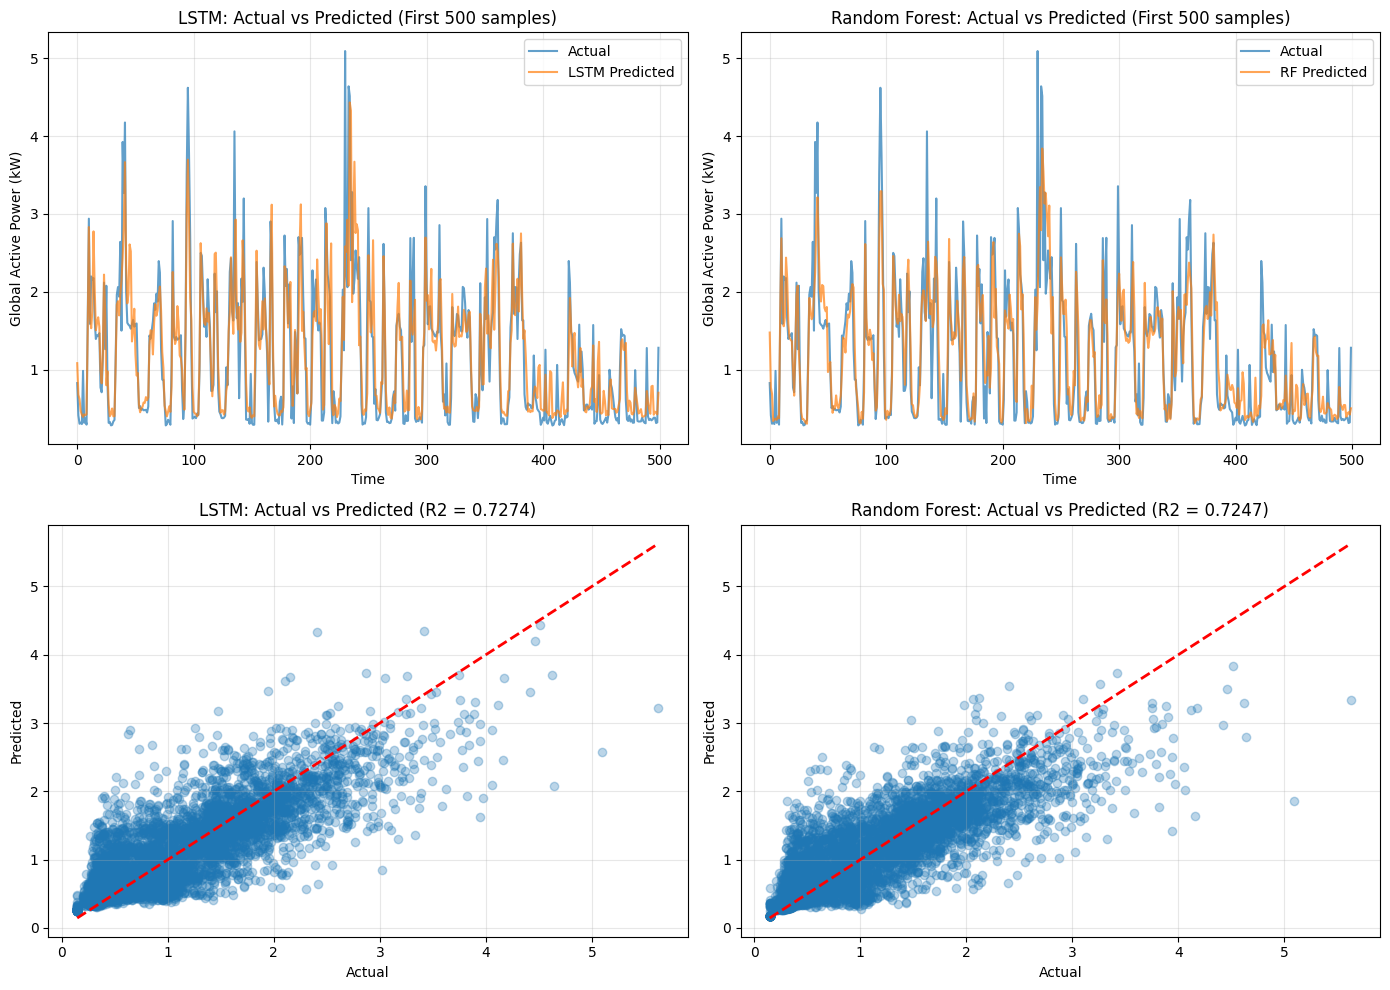

In [24]:
# Visualize predictions comparison
plt.figure(figsize=(14, 10))

# Plot 1: Actual vs Predicted (LSTM)
plt.subplot(2, 2, 1)
plt.plot(y_test.values[:500], label='Actual', alpha=0.7)
plt.plot(y_pred_lstm[:500], label='LSTM Predicted', alpha=0.7)
plt.title('LSTM: Actual vs Predicted (First 500 samples)')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Random Forest)
plt.subplot(2, 2, 2)
plt.plot(y_test.values[:500], label='Actual', alpha=0.7)
plt.plot(y_pred_rf[:500], label='RF Predicted', alpha=0.7)
plt.title('Random Forest: Actual vs Predicted (First 500 samples)')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Scatter plot LSTM
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred_lstm, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'LSTM: Actual vs Predicted (R2 = {lstm_r2:.4f})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)

# Plot 4: Scatter plot Random Forest
plt.subplot(2, 2, 4)
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Random Forest: Actual vs Predicted (R2 = {rf_r2:.4f})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

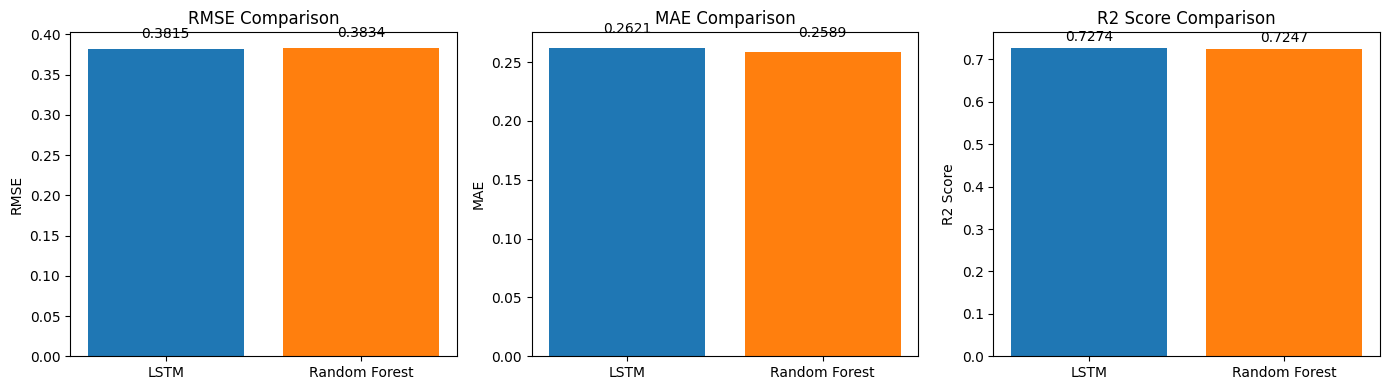

In [25]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['RMSE', 'MAE', 'R2 Score']
lstm_values = [lstm_rmse, lstm_mae, lstm_r2]
rf_values = [rf_rmse, rf_mae, rf_r2]

for i, (metric, lstm_val, rf_val) in enumerate(zip(metrics, lstm_values, rf_values)):
    axes[i].bar(['LSTM', 'Random Forest'], [lstm_val, rf_val], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    for j, v in enumerate([lstm_val, rf_val]):
        axes[i].text(j, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [26]:
# Mount Google Drive to save models
from google.colab import drive
drive.mount('/content/drive')

# Create models directory
models_dir = '/content/drive/My Drive/energy_forecasting_models'
os.makedirs(models_dir, exist_ok=True)

print(f"Models will be saved to: {models_dir}")

Mounted at /content/drive
Models will be saved to: /content/drive/My Drive/energy_forecasting_models


In [27]:
# Save the Random Forest model
import joblib

joblib.dump(model_rf, f'{models_dir}/random_forest_model.pkl')
joblib.dump(scaler_X, f'{models_dir}/scaler_X.pkl')
joblib.dump(scaler_y, f'{models_dir}/scaler_y.pkl')

print("Random Forest model and scalers saved!")

# Save LSTM model
model_lstm.save(f'{models_dir}/lstm_model.keras')
print("LSTM model saved!")

# Verify saved files
print("\nSaved files:")
print(os.listdir(models_dir))

Random Forest model and scalers saved!
LSTM model saved!

Saved files:
['random_forest_model.pkl', 'scaler_X.pkl', 'scaler_y.pkl', 'lstm_model.keras']


In [28]:
# Final Summary
print("\n" + "=" * 60)
print("SMART ENERGY CONSUMPTION FORECASTING - SUMMARY")
print("=" * 60)

print("\nDataset: UCI Individual Household Electric Power Consumption")
print(f"   - Original samples: ~2,075,259")
print(f"   - After preprocessing: {len(df_resampled)} samples (hourly)")

print("\nFeature Engineering:")
print(f"   - Time features: hour, day_of_week, month, day_of_year")
print(f"   - Lag features: 1, 2, 3, 6, 12, 24 hours")
print(f"   - Rolling features: 6h and 24h mean, 24h std")
print(f"   - Total features: {len(feature_columns)}")

print("\nModels Used:")
print("   1. LSTM (Long Short-Term Memory) - Deep Learning")
print("   2. Random Forest - Ensemble Learning")

print("\nModel Performance Comparison:")
print("-" * 60)
print(f"{'Model':<20} {'RMSE':<12} {'MAE':<12} {'R2 Score':<12}")
print("-" * 60)
print(f"{'LSTM':<20} {lstm_rmse:<12.4f} {lstm_mae:<12.4f} {lstm_r2:<12.4f}")
print(f"{'Random Forest':<20} {rf_rmse:<12.4f} {rf_mae:<12.4f} {rf_r2:<12.4f}")
print("-" * 60)

best_model = "LSTM" if lstm_rmse < rf_rmse else "Random Forest"
print(f"\nBest Model (based on RMSE): {best_model}")

print("\nSaved Models (in Google Drive):")
print(f"   - {models_dir}/random_forest_model.pkl")
print(f"   - {models_dir}/lstm_model.keras")
print(f"   - {models_dir}/scaler_X.pkl, scaler_y.pkl")

print("\n" + "=" * 60)


SMART ENERGY CONSUMPTION FORECASTING - SUMMARY

Dataset: UCI Individual Household Electric Power Consumption
   - Original samples: ~2,075,259
   - After preprocessing: 34565 samples (hourly)

Feature Engineering:
   - Time features: hour, day_of_week, month, day_of_year
   - Lag features: 1, 2, 3, 6, 12, 24 hours
   - Rolling features: 6h and 24h mean, 24h std
   - Total features: 13

Models Used:
   1. LSTM (Long Short-Term Memory) - Deep Learning
   2. Random Forest - Ensemble Learning

Model Performance Comparison:
------------------------------------------------------------
Model                RMSE         MAE          R2 Score    
------------------------------------------------------------
LSTM                 0.3815       0.2621       0.7274      
Random Forest        0.3834       0.2589       0.7247      
------------------------------------------------------------

Best Model (based on RMSE): LSTM

Saved Models (in Google Drive):
   - /content/drive/My Drive/energy_forecast